# **Project Title:**
Prediction market (Polymarket)

by Songqiao Qi

## Project objective:
Analyze open Polymarket activity and evaluate whether pre-announcement trading around the US-Iran ceasefire event shows abnormal wallet trading behavior.

## Data overview:
- Primary data APIs: Polymarket Gamma API and Dune API.
- Analytical APIs: Vertex AI, Claude API, and Azure OpenAI API.
- Timeframe: platform context (open events) and a case window (April 7, 2026).
- Focus of analysis: event-level metrics and wallet-level trade behavior.

<img src="polymarket_project_flow_v6.svg" alt="Polymarket Project Flow" width="760"/>


## Part A: General Polymarket Analysis

### D1. Library imports


In [1]:
import os
import time
from typing import Any, Dict, List, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.2f}".format

GAMMA_BASE = "https://gamma-api.polymarket.com"
DEFAULT_HEADERS = {
    "Accept": "application/json",
    "User-Agent": "polymarket-analysis-notebook/1.0",
}
REQUEST_TIMEOUT = 20

### D2. Data pre-processing


In [ ]:
def request_json(
    path: str,
    params: Optional[Dict[str, Any]] = None,
    max_retries: int = 3,
    backoff_seconds: float = 1.25,
) -> Any:
    params = params or {}
    last_error: Optional[Exception] = None
    url = f"{GAMMA_BASE}{path}"

    for attempt in range(1, max_retries + 1):
        try:
            response = requests.get(url, params=params, headers=DEFAULT_HEADERS, timeout=REQUEST_TIMEOUT)
            response.raise_for_status()
            return response.json()
        except Exception as exc:
            last_error = exc
            if attempt < max_retries:
                time.sleep(backoff_seconds * attempt)

    raise RuntimeError(f"Failed to fetch {path}") from last_error


def fetch_paginated(
    path: str,
    page_size: int = 100,
    max_pages: Optional[int] = None,
    extra_params: Optional[Dict[str, Any]] = None,
) -> pd.DataFrame:
    all_records: List[Dict[str, Any]] = []
    page = 0
    while True:
        params = {"limit": page_size, "offset": page * page_size}
        if extra_params:
            params.update(extra_params)

        data = request_json(path, params=params)
        records = data if isinstance(data, list) else (data.get("data") or data.get("events") or [])

        if not records:
            break

        all_records.extend(records)
        if len(records) < page_size:
            break

        page += 1
        if max_pages is not None and page >= max_pages:
            break

    return pd.DataFrame(all_records)


def _derive_event_category(row: pd.Series) -> str:
    tags = row.get("tags") or []
    if isinstance(tags, list):
        for t in tags:
            if isinstance(t, dict):
                label = t.get("label") or t.get("name")
                if isinstance(label, str) and label.strip():
                    return label.strip()

    series = row.get("series")
    if isinstance(series, dict):
        name = series.get("name") or series.get("slug")
        if isinstance(name, str) and name.strip():
            return name.strip()

    return "uncategorized"


EVENTS_PAGE_SIZE = 100
EVENTS_QUERY_PARAMS = {"closed": "false", "active": "true"}

events_raw = fetch_paginated(
    "/events",
    page_size=EVENTS_PAGE_SIZE,
    extra_params=EVENTS_QUERY_PARAMS,
)

events_raw["derived_category"] = events_raw.apply(_derive_event_category, axis=1)

for col in ("volume", "liquidity", "openInterest"):
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce")
events_raw["createdAt"] = pd.to_datetime(events_raw["createdAt"], errors="coerce", utc=True)

print(f"Open events fetched: {len(events_raw):,}")

Open events fetched: 10,798


#### Data profiling and field preparation


In [3]:
display(events_raw.dtypes.to_frame().T)

,id,ticker,slug,title,description,resolutionSource,startDate,creationDate,endDate,image,icon,active,closed,archived,new,featured,restricted,liquidity,volume,openInterest,createdAt,updatedAt,competitive,volume24hr,volume1wk,volume1mo,volume1yr,enableOrderBook,liquidityClob,negRisk,commentCount,markets,tags,cyom,showAllOutcomes,showMarketImages,enableNegRisk,automaticallyActive,gmpChartMode,negRiskAugmented,cumulativeMarkets,pendingDeployment,deploying,requiresTranslation,eventMetadata,estimateValue,featuredOrder,startTime,countryName,sortBy,eventCreators,negRiskMarketID,deployingTimestamp,series,seriesSlug,eventDate,color,createdBy,electionType,eventWeek,score,elapsed,period,live,ended,finishedTimestamp,gameId,teams,cantEstimate,estimatedValue,parentEventId,tweetCount,closedTime,liquidityAmm,derived_category
0,str,str,str,str,str,str,str,str,str,str,str,bool,bool,bool,bool,bool,bool,float64,float64,float64,"datetime64[us, UTC]",str,float64,float64,float64,float64,float64,bool,float64,object,int64,object,object,bool,bool,bool,bool,object,str,bool,object,bool,bool,bool,object,object,float64,str,str,str,object,str,str,object,str,str,str,str,str,float64,str,str,str,object,object,str,float64,object,object,str,float64,float64,str,float64,str


In [ ]:
# save to 2 decimals
# Keep these in raw USD (2 decimals)
raw_2dp_cols = ["liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob"]
for col in raw_2dp_cols:
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce").round(2)

# Keep these as USD mn (2 decimals)
mn_source_cols = ["volume", "volume1wk", "volume1mo", "volume1yr"]
for col in mn_source_cols:
    events_raw[col] = pd.to_numeric(events_raw[col], errors="coerce")
    events_raw[f"{col}_mn"] = (events_raw[col] / 1_000_000).round(2)

display_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]
display(events_raw[display_cols].head(3))

print("Top derived categories in open events:")
display(events_raw["derived_category"].value_counts(dropna=False).head(15).to_frame("count"))

,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
0,16167,MicroStrategy sells any Bitcoin by ___ ?,microstrategy-sell-any-bitcoin-in-2025,22.22,9.15,15.81,19.50,"127,302.11","491,366.05",0.87,"5,532.23","127,302.11",Finance
1,16183,Kraken IPO by ___ ?,kraken-ipo-in-2025,1.53,0.09,0.30,0.98,"3,415.17","59,589.09",0.95,802.62,"3,415.17",exchange
2,16263,Macron out by...?,macron-out-in-2025,1.92,0.06,0.46,1.92,"81,163.24","69,220.94",0.81,"17,279.38","81,163.24",France


Top derived categories in open events:


,count
derived_category,
Sports,3834
Up or Down,2179
Crypto,562
Politics,524
Esports,415
Elections,226
Crypto Prices,208
Weather,169
Hide From New,150


### D3. Data analysis

#### Question 1
Which are the most actively traded Polymarket events currently (top 2)?

##### Answer
Top 2 open events by total traded volume (USD mn):
Democratic Presidential Nominee 2028 (`id=30829`) — **$1,069.65M** as of Apr 22
2026 FIFA World Cup Winner (`id=30615`) — **$683.42M** as of Apr 22

#### Question 2
What kinds of events are currently being traded?

##### Answer
The open-event universe is mostly recurring sports and directional markets, politics and crypto also active. Participation appears broad, but activity is concentrated in a few categories.

Top categories:
- **Sports:** 3,834
- **Up or Down:** 2,179
- **Crypto:** 562
- **Politics:** 524
- **Esports:** 415
- **Elections:** 226

#### Question 3
Can LLM agents be used in prediction-market trading?

##### Answer
**Yes, but mainly as decision-support rather than autonomous execution.**

In this notebook test, three models (Gemini 3 Flash, Claude Sonnet 4.6, GPT 5.3) produced the same pick (**Spain**) with low confidence (**16/100**). 

Some practical use today:
- event screening and hypothesis generation,
- parsing market metadata and translating it into structured signals,

Why trading agents does not work:
- Trading requires trader to understand market participants' expectation, which is primate information. LLM does not have and will not have enough data to train on.

In [ ]:
rank_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]

print("Top 10 open events by volume")
display(events_raw.sort_values("volume", ascending=False)[rank_cols].head(10))

Top 10 open events by volume


,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,"1,069.65",42.84,209.77,"1,069.65","51,459,309.76","11,947,708.33",0.95,"10,376,306.06","51,459,309.76",World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,683.42,113.55,351.66,674.75,"156,681,304.95","8,579,748.63",0.90,"8,777,388.14","156,681,304.95",Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,566.74,22.67,133.05,566.74,"29,403,986.32","8,328,558.75",0.99,"3,836,255.53","29,403,986.32",Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,538.74,23.28,113.04,538.74,"29,199,253.49","40,540,734.23",0.91,"2,648,868.83","29,199,253.49",World Elections
49,33507,English Premier League Winner,english-premier-league-winner,317.36,12.31,43.95,191.87,"3,899,512.24","3,682,378.18",0.99,"100,609.24","3,899,512.24",Sports
26,27830,2026 NBA Champion,2026-nba-champion,288.38,37.52,95.59,226.11,"7,216,687.52","4,949,086.84",1.00,"6,054,177.20","7,216,687.52",Sports
48,33506,UEFA Champions League Winner,uefa-champions-league-winner,243.03,20.67,63.92,213.25,"2,488,857.95","2,222,884.40",0.98,"685,491.94","2,488,857.95",Soccer
60,34051,Netanyahu out by...?,netanyahu-out-before-2027,117.48,1.17,11.48,13.28,"465,305.64","3,182,285.99",1.00,"77,344.23","465,305.64",World
638,100371,F1 Drivers' Champion,2026-f1-drivers-champion,111.44,16.88,77.77,111.44,"12,171,926.47","1,146,679.61",0.99,"2,208,176.48","12,171,926.47",Sports
348,75478,Fed decision in April?,fed-decision-in-april,111.15,37.93,101.37,111.15,"15,474,034.68","16,172,934.09",0.80,"3,648,330.01","15,474,034.68",Economic Policy


#### Event visualization


Top 10 open events by volume


,id,title,slug,volume_mn,volume1wk_mn,volume1mo_mn,volume1yr_mn,liquidity,openInterest,competitive,volume24hr,liquidityClob,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,"1,069.65",42.84,209.77,"1,069.65","51,459,309.76","11,947,708.33",0.95,"10,376,306.06","51,459,309.76",World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,683.42,113.55,351.66,674.75,"156,681,304.95","8,579,748.63",0.90,"8,777,388.14","156,681,304.95",Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,566.74,22.67,133.05,566.74,"29,403,986.32","8,328,558.75",0.99,"3,836,255.53","29,403,986.32",Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,538.74,23.28,113.04,538.74,"29,199,253.49","40,540,734.23",0.91,"2,648,868.83","29,199,253.49",World Elections
49,33507,English Premier League Winner,english-premier-league-winner,317.36,12.31,43.95,191.87,"3,899,512.24","3,682,378.18",0.99,"100,609.24","3,899,512.24",Sports
26,27830,2026 NBA Champion,2026-nba-champion,288.38,37.52,95.59,226.11,"7,216,687.52","4,949,086.84",1.00,"6,054,177.20","7,216,687.52",Sports
48,33506,UEFA Champions League Winner,uefa-champions-league-winner,243.03,20.67,63.92,213.25,"2,488,857.95","2,222,884.40",0.98,"685,491.94","2,488,857.95",Soccer
60,34051,Netanyahu out by...?,netanyahu-out-before-2027,117.48,1.17,11.48,13.28,"465,305.64","3,182,285.99",1.00,"77,344.23","465,305.64",World
638,100371,F1 Drivers' Champion,2026-f1-drivers-champion,111.44,16.88,77.77,111.44,"12,171,926.47","1,146,679.61",0.99,"2,208,176.48","12,171,926.47",Sports
348,75478,Fed decision in April?,fed-decision-in-april,111.15,37.93,101.37,111.15,"15,474,034.68","16,172,934.09",0.80,"3,648,330.01","15,474,034.68",Economic Policy


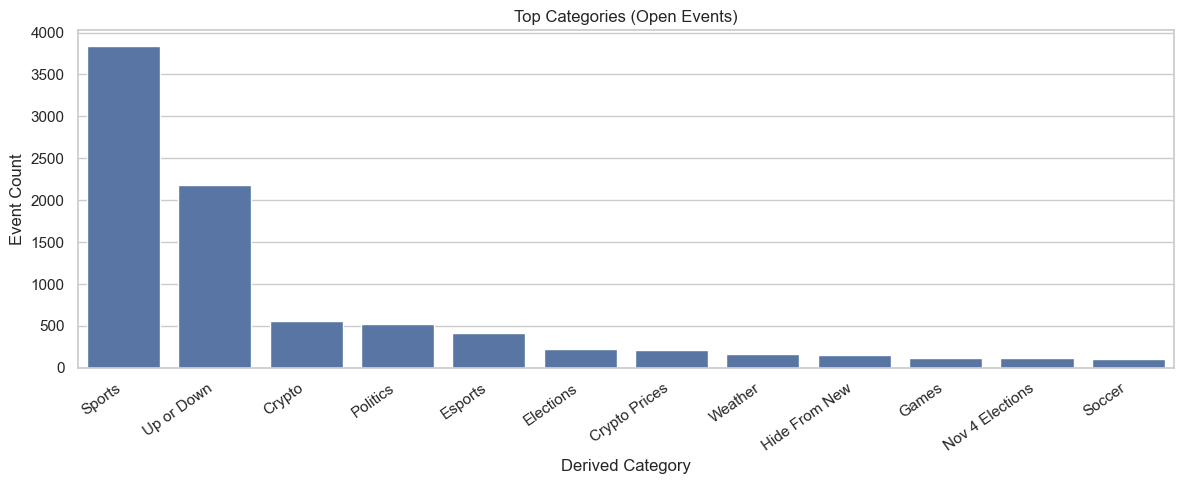

In [ ]:
events_viz = events_raw.copy()

top_events_viz = events_viz.sort_values("volume", ascending=False).head(10).copy()
show_cols = [
    "id", "title", "slug",
    "volume_mn", "volume1wk_mn", "volume1mo_mn", "volume1yr_mn",
    "liquidity", "openInterest", "competitive", "volume24hr", "liquidityClob",
    "derived_category"
]

print("Top 10 open events by volume")
display(top_events_viz[show_cols])

top_category = (
    events_viz["derived_category"]
    .fillna("uncategorized")
    .value_counts()
    .head(1)
    .rename_axis("derived_category")
    .reset_index(name="event_count")
)

# chart for derived categories
cat_counts = (
    events_viz["derived_category"]
    .fillna("uncategorized")
    .value_counts()
    .head(12)
    .reset_index()
)
cat_counts.columns = ["derived_category", "event_count"]
plt.figure(figsize=(12, 5))
sns.barplot(data=cat_counts, x="derived_category", y="event_count")
plt.title("Top Categories (Open Events)")
plt.xlabel("Derived Category")
plt.ylabel("Event Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

#### Persist cleaned outputs


In [ ]:
output_dir = "./polymarket_outputs"
os.makedirs(output_dir, exist_ok=True)

events_path = os.path.join(output_dir, "events_open_raw.csv")
events_raw.to_csv(events_path, index=False, mode="w")

print(f"Saved: {os.path.abspath(events_path)}")

Saved: /Users/qisongqiao/Warehouse/nyu_course_homework/TECH-GB.2148-01_DealingwithData/project/polymarket_outputs/events_open_raw.csv


In [8]:
top_events = events_raw.sort_values("volume", ascending=False).head(5).copy()

show_cols = ["id", "title", "slug", "volume_mn", "active", "closed", "derived_category"]
print("Top 5 open events by volume (USD mn):")
display(top_events[show_cols])

Top 5 open events by volume (USD mn):


,id,title,slug,volume_mn,active,closed,derived_category
33,30829,Democratic Presidential Nominee 2028,democratic-presidential-nominee-2028,"1,069.65",True,False,World Elections
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,683.42,True,False,Soccer
37,31875,Republican Presidential Nominee 2028,republican-presidential-nominee-2028,566.74,True,False,Politics
35,31552,Presidential Election Winner 2028,presidential-election-winner-2028,538.74,True,False,World Elections
49,33507,English Premier League Winner,english-premier-league-winner,317.36,True,False,Sports


In [9]:
!pip install google-auth anthropic openai #only once

In [ ]:
import json
import google.auth
from google.auth.transport.requests import Request
from anthropic import Anthropic
from openai import AzureOpenAI
from urllib.parse import urlparse

# Load .env values
if os.path.exists(".env"):
    with open(".env", "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or "=" not in s:
                continue
            k, v = s.split("=", 1)
            os.environ[k.strip()] = v.strip().strip('"').strip("'")

# Vertex setup
creds, default_project = google.auth.default(scopes=["https://www.googleapis.com/auth/cloud-platform"])
if (not creds.valid) or creds.expired or (not creds.token):
    creds.refresh(Request())

VERTEX_PROJECT_ID = os.getenv("VERTEX_PROJECT_ID", "").strip() 
VERTEX_LOCATION = os.getenv("VERTEX_LOCATION", "global").strip()
VERTEX_MODEL = os.getenv("VERTEX_MODEL", "gemini-3-flash-preview").strip()

VERTEX_API_HOST = "aiplatform.googleapis.com" if VERTEX_LOCATION == "global" else f"{VERTEX_LOCATION}-aiplatform.googleapis.com"
vertex_endpoint = (
    f"https://{VERTEX_API_HOST}/v1/projects/{VERTEX_PROJECT_ID}/locations/{VERTEX_LOCATION}"
    f"/publishers/google/models/{VERTEX_MODEL}:generateContent"
)
vertex_headers = {
    "Authorization": f"Bearer {creds.token}",
    "Content-Type": "application/json",
}

# Claude setup
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "").strip()
CLAUDE_MODEL = os.getenv("CLAUDE_MODEL", "").strip() 
claude_client = Anthropic(api_key=ANTHROPIC_API_KEY) if ANTHROPIC_API_KEY else None

# Azure GPT setup
raw_azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT", "").strip()
AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY", "").strip()
AZURE_OPENAI_API_VERSION = os.getenv("AZURE_OPENAI_API_VERSION", "").strip() 
AZURE_OPENAI_DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT", "").strip()

if raw_azure_endpoint and not raw_azure_endpoint.startswith(("http://", "https://")):
    raw_azure_endpoint = "https://" + raw_azure_endpoint
parsed = urlparse(raw_azure_endpoint)
AZURE_OPENAI_ENDPOINT = f"{parsed.scheme}://{parsed.netloc}" if parsed.scheme and parsed.netloc else raw_azure_endpoint
AZURE_OPENAI_ENDPOINT = AZURE_OPENAI_ENDPOINT.rstrip("/")

azure_client = AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_OPENAI_API_VERSION,
)

# One test prompt
test_prompt = "Is the earth flat? Answer with yes or no only. Do not provide any explanation or additional narrative. Also return the # token consumed for this conversation as a single number after Yes/No"

# Vertex test
vertex_payload = {
    "contents": [{"role": "user", "parts": [{"text": test_prompt}]}],
    "generationConfig": {"temperature": 0.0, "maxOutputTokens": 256},
}
vertex_resp = requests.post(vertex_endpoint, headers=vertex_headers, json=vertex_payload, timeout=60)
vertex_resp.raise_for_status()
vertex_json = vertex_resp.json()
vertex_test = ""
vertex_candidates = vertex_json.get("candidates", [])
if vertex_candidates:
    vertex_parts = vertex_candidates[0].get("content", {}).get("parts", [])
    vertex_test = "".join(str(part.get("text", "")) for part in vertex_parts if isinstance(part, dict)).strip()
if not vertex_test:
    vertex_test = f"(no text) promptFeedback={vertex_json.get('promptFeedback', {})}"
print("Vertex Gemini test:", vertex_test)

# Claude test
if claude_client:
    claude_msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=256,
        temperature=0.0,
        messages=[{"role": "user", "content": test_prompt}],
    )
    claude_test = "".join(block.text for block in claude_msg.content if getattr(block, "type", "") == "text").strip()
    print("Claude test:", claude_test)
else:
    print("Claude test: ANTHROPIC_API_KEY missing in .env")

# Azure GPT test
gpt_test_resp = azure_client.responses.create(
    model=AZURE_OPENAI_DEPLOYMENT,
    input=test_prompt,
    max_output_tokens=256,
)
gpt_test = (getattr(gpt_test_resp, "output_text", "") or "").strip()
if not gpt_test:
    raise RuntimeError("Azure GPT test returned empty output_text")
print("Azure GPT test:", gpt_test)

Vertex Gemini test: No 52
Claude test: No. 16
Azure GPT test: No, unknown


In [ ]:
SELECTED_EVENT_ID = "30615"

top_events = events_raw.sort_values("volume", ascending=False).head(5).copy()
selected = top_events[top_events["id"].astype(str) == str(SELECTED_EVENT_ID).strip()]

row = selected.iloc[0]
print("Selected event:")
display(selected[["id", "title", "slug", "volume_mn", "derived_category"]])

event_title = str(row.get("title", row.get("slug", "")))
event_slug = str(row.get("slug", ""))
event_volume_mn = float(row.get("volume_mn") or 0)
event_desc = str(row.get("description", ""))[:1200]

markets_obj = row.get("markets", [])
try:
    markets_json = json.dumps(markets_obj, ensure_ascii=False, default=str)
except Exception:
    markets_json = str(markets_obj)

prompt_text = (
    "You are a sports prediction-market analyst. "
    "Given this one championship event and its nested market JSON, predict the most likely champion. "
    "Return only: predicted champion, confidence (0-100).\n\n"
    f"event_id: {row.get('id', '')}\n"
    f"event_title: {event_title}\n"
    f"event_slug: {event_slug}\n"
    f"volume_usd_mn: {event_volume_mn:,.2f}\n"
    f"description: {event_desc}\n\n"
    f"markets_nested_json: {markets_json}"
)

# Vertex query
vertex_payload = {
    "contents": [{"role": "user", "parts": [{"text": prompt_text}]}],
    "generationConfig": {"temperature": 0.3, "maxOutputTokens": 2048},
}
vertex_resp = requests.post(vertex_endpoint, headers=vertex_headers, json=vertex_payload, timeout=60)
vertex_resp.raise_for_status()
vertex_json = vertex_resp.json()
vertex_text = ""
vc = vertex_json.get("candidates", [])
if vc:
    parts = vc[0].get("content", {}).get("parts", [])
    vertex_text = "".join(str(p.get("text", "")) for p in parts if isinstance(p, dict)).strip()

# Claude query
if claude_client:
    claude_msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=2048,
        temperature=0.3,
        messages=[{"role": "user", "content": prompt_text}],
    )
    claude_text = "".join(block.text for block in claude_msg.content if getattr(block, "type", "") == "text").strip()
else:
    claude_text = "ANTHROPIC_API_KEY missing in .env"

# Azure GPT query
gpt_resp = azure_client.responses.create(
    model=AZURE_OPENAI_DEPLOYMENT,
    input=prompt_text,
    max_output_tokens=2048,
)
gpt_text = (getattr(gpt_resp, "output_text", "") or "").strip()
if not gpt_text:
    parts = []
    for item in getattr(gpt_resp, "output", []) or []:
        for content in getattr(item, "content", []) or []:
            if getattr(content, "type", "") in {"output_text", "text"}:
                t = getattr(content, "text", "")
                if t:
                    parts.append(t)
    gpt_text = "\n".join(parts).strip()

print("\n===== Gemini 3 Flash =====\n")
print(vertex_text if vertex_text else "(empty response)")

print("\n===== Claude Sonnet 4.6 =====\n")
print(claude_text if claude_text else "(empty response)")

print("\n===== GPT 5.3 =====\n")
print(gpt_text if gpt_text else "(empty response)")

Selected event:


,id,title,slug,volume_mn,derived_category
30,30615,2026 FIFA World Cup Winner,2026-fifa-world-cup-winner-595,683.42,Soccer



===== Gemini 3 Flash =====

Spain, 16

===== Claude Sonnet 4.6 =====

**Predicted Champion: Spain**
**Confidence: 16**

===== GPT 5.3 =====

Spain, 16


### D4. Summary of key findings


### D5. Further research


## Part B: Abnormal (potential insider) trading


### D2. Data pre-processing


In [12]:
EVENT_SLUG = "us-x-iran-ceasefire-by"
ANCHOR_TS_UTC = pd.Timestamp("2026-04-07T22:32:00Z")
PRE_WINDOW_HOURS = 5
PRE_WINDOW_START_UTC = ANCHOR_TS_UTC - pd.Timedelta(hours=PRE_WINDOW_HOURS)

GAMMA_BASE = "https://gamma-api.polymarket.com"
DUNE_API_BASE = "https://api.dune.com/api/v1"

load_dotenv()
DUNE_API_KEY = os.getenv("DUNE_API_KEY", "").strip()

OUTPUT_DIR = Path("./polymarket_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Anchor UTC:", ANCHOR_TS_UTC)
print("Pre-window:", PRE_WINDOW_START_UTC, "to", ANCHOR_TS_UTC)

Anchor UTC: 2026-04-07 22:32:00+00:00
Pre-window: 2026-04-07 17:32:00+00:00 to 2026-04-07 22:32:00+00:00


#### Event retrieval and pre-window setup


In [ ]:
def gamma_get(path: str, params: dict | None = None) -> list | dict:
    r = requests.get(f"{GAMMA_BASE}{path}", params=params or {}, timeout=30)
    r.raise_for_status()
    return r.json()


def load_event_by_slug(slug: str) -> dict:
    data = gamma_get("/events", params={"slug": slug})
    if isinstance(data, list) and data:
        return data[0]
    if isinstance(data, dict) and data:
        return data
    raise ValueError(f"Event not found for slug={slug}")


def parse_market_launch_time(df: pd.DataFrame) -> pd.Series:
    created = pd.to_datetime(df.get("createdAt"), errors="coerce", utc=True)
    started = pd.to_datetime(df.get("startDate"), errors="coerce", utc=True)
    launch = started.combine_first(created)
    return launch


event = load_event_by_slug(EVENT_SLUG)
print("event_id:", event.get("id"))
print("event_title:", event.get("title"))
print("event_closed:", event.get("closed"))

submarkets = pd.json_normalize(event.get("markets", []), sep=".")
if submarkets.empty:
    raise ValueError("No submarkets found under target event.")

for c in ["createdAt", "startDate", "endDate", "updatedAt"]:
    submarkets[c] = pd.to_datetime(submarkets[c], errors="coerce", utc=True)

# Only process numeric fields used downstream
submarkets["volume"] = pd.to_numeric(submarkets["volume"], errors="coerce")
submarkets["volume_mn"] = (submarkets["volume"] / 1_000_000).round(2)

submarkets["launch_time"] = parse_market_launch_time(submarkets)
submarkets_pre_anchor = submarkets[submarkets["launch_time"] <= ANCHOR_TS_UTC].copy()

keep_cols = [
    "id", "slug", "question", "active", "closed",
    "launch_time", "createdAt", "startDate", "endDate",
    "volume_mn", "conditionId", "clobTokenIds"
]

print(f"Submarkets total: {len(submarkets):,}")
print(f"Submarkets pre-anchor: {len(submarkets_pre_anchor):,}")
display(submarkets_pre_anchor.sort_values("volume_mn", ascending=False)[keep_cols].head(30))

submarkets_pre_anchor.to_csv(OUTPUT_DIR / "case_ceasefire_selected_submarkets.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_selected_submarkets.csv")

event_id: 236840
event_title: US x Iran ceasefire by...?
event_closed: True
Submarkets total: 12
Submarkets pre-anchor: 12


,id,slug,question,active,closed,launch_time,createdAt,startDate,endDate,volume_mn,conditionId,clobTokenIds
9,1706788,us-x-iran-ceasefire-by-april-7,US x Iran ceasefire by April 7?,True,True,2026-03-24 17:55:37.794489+00:00,2026-03-24 17:52:05.724561+00:00,2026-03-24 17:55:37.794489+00:00,2026-04-07 00:00:00+00:00,173.70,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,"[""82855088893985825781350466813737280564000275..."
0,1466015,us-x-iran-ceasefire-by-march-31,US x Iran ceasefire by March 31?,True,True,2026-02-28 13:55:27.406367+00:00,2026-02-28 13:44:02.418340+00:00,2026-02-28 13:55:27.406367+00:00,NaT,44.38,0x3c6bcb7da14ea576e5af25547dbd96f2bb24ac34e748...,"[""57085616606014598055128171316012304939715897..."
8,1569627,us-x-iran-ceasefire-by-april-15,US x Iran ceasefire by April 15?,True,True,2026-03-12 17:06:47.252000+00:00,2026-03-12 16:42:24.632357+00:00,2026-03-12 17:06:47.252000+00:00,2026-04-15 00:00:00+00:00,24.62,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,"[""85191934649046129480174964255278880752271767..."
1,1466016,us-x-iran-ceasefire-by-april-30,US x Iran ceasefire by April 30?,True,True,2026-02-28 13:55:23.403000+00:00,2026-02-28 13:44:03.127118+00:00,2026-02-28 13:55:23.403000+00:00,NaT,17.73,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...,"[""44149007410374101286260953227333745102128417..."
7,1484894,us-x-iran-ceasefire-by-may-825,US x Iran ceasefire by May 31?,True,True,2026-03-02 17:21:12.961000+00:00,2026-03-02 17:03:42.044363+00:00,2026-03-02 17:21:12.961000+00:00,2026-05-31 00:00:00+00:00,7.79,0xa9937410f8aae98cc6440a7480ad832be5a1a998afcf...,"[""97390751868769233430161550786035197721004217..."
6,1484895,us-x-iran-ceasefire-by-june-30,US x Iran ceasefire by June 30?,True,True,2026-03-02 17:51:15.382000+00:00,2026-03-02 17:04:03.295238+00:00,2026-03-02 17:51:15.382000+00:00,2026-06-30 00:00:00+00:00,5.03,0x81b06cb917c9a2aabc67a7765bc3c640e88a699bbf45...,"[""91234452361450605263734013436205650165110345..."
4,1466012,us-x-iran-ceasefire-by-march-2,US x Iran ceasefire by March 2?,True,True,2026-02-28 13:55:25.297000+00:00,2026-02-28 13:44:00.441254+00:00,2026-02-28 13:55:25.297000+00:00,NaT,3.49,0x184f4a327edc0cd0af1f409980f6cc8d227fa9685562...,"[""89776833499647348615695457645016543876782311..."
5,1571566,us-x-iran-ceasefire-by-december-31,US x Iran ceasefire by December 31?,True,True,2026-03-12 21:33:38.098000+00:00,2026-03-12 21:30:30.966459+00:00,2026-03-12 21:33:38.098000+00:00,2026-12-31 00:00:00+00:00,2.11,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...,"[""81289454586466989038065696325544201866984980..."
11,1912494,us-x-iran-ceasefire-by-april-10,US x Iran ceasefire by April 10?,True,True,2026-04-07 21:54:59.039461+00:00,2026-04-07 21:50:59.559310+00:00,2026-04-07 21:54:59.039461+00:00,2026-04-10 00:00:00+00:00,0.87,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,"[""79960339234673242042984505667380376808663520..."
10,1896585,us-x-iran-ceasefire-by-may,US x Iran ceasefire by May 15?,True,True,2026-04-06 21:27:57.779000+00:00,2026-04-06 21:22:28.129696+00:00,2026-04-06 21:27:57.779000+00:00,2026-05-15 00:00:00+00:00,0.42,0xd9a8b5917a3bc25caf28784fddac39bc45a9f2fe4c63...,"[""72218628059411750242900835703049011068181898..."


Saved: polymarket_outputs/case_ceasefire_selected_submarkets.csv


#### Dune API query helpers


In [ ]:
def dune_headers(api_key: str) -> dict:
    return {"X-Dune-Api-Key": api_key, "Content-Type": "application/json"}


def dune_execute_sql(sql: str, api_key: str, performance: str = "medium") -> str:
    if not api_key:
        raise ValueError("Missing DUNE_API_KEY. Set env var DUNE_API_KEY.")

    r = requests.post(
        f"{DUNE_API_BASE}/sql/execute",
        headers=dune_headers(api_key),
        json={"sql": sql, "performance": performance},
        timeout=30,
    )
    if not r.ok:
        raise RuntimeError(f"Dune execute failed: HTTP {r.status_code} | {r.text[:500]}")

    out = r.json()
    execution_id = out.get("execution_id")
    if not execution_id:
        raise RuntimeError(f"No execution_id returned: {out}")
    return execution_id


def dune_get_execution_status(execution_id: str, api_key: str) -> dict:
    r = requests.get(
        f"{DUNE_API_BASE}/execution/{execution_id}/status",
        headers=dune_headers(api_key),
        timeout=30,
    )
    if not r.ok:
        raise RuntimeError(f"Dune status failed: HTTP {r.status_code} | {r.text[:500]}")
    return r.json()


def dune_get_execution_results(
    execution_id: str,
    api_key: str,
    allow_partial_results: bool = True,
    limit: int | None = None,
) -> dict:
    params = {"allow_partial_results": str(allow_partial_results).lower()}
    if limit is not None:
        params["limit"] = int(limit)

    r = requests.get(
        f"{DUNE_API_BASE}/execution/{execution_id}/results",
        headers=dune_headers(api_key),
        params=params,
        timeout=60,
    )
    if not r.ok:
        raise RuntimeError(f"Dune results failed: HTTP {r.status_code} | {r.text[:500]}")
    return r.json()


def dune_run_sql(
    sql: str,
    api_key: str,
    performance: str = "medium",
    poll_interval_seconds: float = 2.0,
    timeout_seconds: float = 300,
    limit: int | None = None,
) -> dict:
    execution_id = dune_execute_sql(sql=sql, api_key=api_key, performance=performance)
    deadline = time.time() + timeout_seconds

    while True:
        status = dune_get_execution_status(execution_id, api_key=api_key)
        state = status.get("state")

        if state in {"QUERY_STATE_COMPLETED", "QUERY_STATE_COMPLETED_PARTIAL"}:
            return dune_get_execution_results(execution_id, api_key=api_key, allow_partial_results=True, limit=limit)

        if state in {"QUERY_STATE_FAILED", "QUERY_STATE_CANCELED", "QUERY_STATE_EXPIRED"}:
            raise RuntimeError(f"Dune query failed: {status}")

        if time.time() > deadline:
            raise TimeoutError(f"Timed out waiting for Dune execution {execution_id}")

        time.sleep(poll_interval_seconds)


def dune_rows_to_df(result_payload: dict) -> pd.DataFrame:
    rows = result_payload.get("result", {}).get("rows", []) if isinstance(result_payload, dict) else []
    return pd.DataFrame(rows)


def sql_quote(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"

#### Event/market resolution


In [ ]:
if not DUNE_API_KEY:
    raise RuntimeError("DUNE_API_KEY missing.")

selected_condition_ids = sorted({
    str(x).strip().lower()
    for x in submarkets_pre_anchor["conditionId"].dropna().tolist()
    if str(x).strip()
})
selected_condition_ids = [x if x.startswith("0x") else f"0x{x}" for x in selected_condition_ids]
print("Selected pre-anchor condition IDs:", len(selected_condition_ids))

condition_sql = ", ".join(sql_quote(c) for c in selected_condition_ids)
mapping_sql = f"""
SELECT DISTINCT
    condition_id,
    event_market_name,
    question,
    token_outcome,
    token_outcome_name,
    unique_key
FROM polymarket_polygon.market_details
WHERE lower(condition_id) IN ({condition_sql})
ORDER BY question, token_outcome
"""

mapping_res = dune_run_sql(mapping_sql, api_key=DUNE_API_KEY, performance="medium", limit=20000)
dune_market_map = dune_rows_to_df(mapping_res)

print("Mapped rows:", len(dune_market_map))
display(dune_market_map.head(5))

dune_market_map.to_csv(OUTPUT_DIR / "case_ceasefire_dune_market_map.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_dune_market_map.csv")

Selected pre-anchor condition IDs: 12
Mapped rows: 24


,condition_id,event_market_name,question,token_outcome,token_outcome_name,unique_key
0,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,single market,US x Iran ceasefire by April 10?,No,No-US x Iran ceasefire by April 10?,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...
1,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,single market,US x Iran ceasefire by April 10?,Yes,Yes-US x Iran ceasefire by April 10?,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...
2,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,single market,US x Iran ceasefire by April 15?,No,No-US x Iran ceasefire by April 15?,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...
3,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,single market,US x Iran ceasefire by April 15?,Yes,Yes-US x Iran ceasefire by April 15?,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...
4,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...,single market,US x Iran ceasefire by April 30?,No,No-US x Iran ceasefire by April 30?,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...


Saved: polymarket_outputs/case_ceasefire_dune_market_map.csv


### D3. Data analysis

#### Question 4
How can trading data be used to detect abnormal (potential insider-like) activity?

##### Answer
1. Find the event and pre-event window around an anchor timestamp.
2. Filter to relevant markets/questions and a meaningful thresholds (omit small trades, usually reail).
3. Build wallet-level features, most important:
   - total notional,
   - YES-vs-NO directional bias,
4. Enrich with wallet metadata (creation/funding time).
5. Flag combinations such as: newly funded wallet + positioning bia + high notional + clustered timing before event information release.

Case metrics used here:
- pre-window rows: **2,251 trades**
- wallets: **632**
- total notional: **$8.44M**
- concentration: top-1 wallet **25.24%**, top-10 wallets **44.34%** of pre-window notional
- direction counts: **510 NO-biased** wallets vs **122 YES-biased** wallets

In [16]:
start_iso = PRE_WINDOW_START_UTC.strftime("%Y-%m-%dT%H:%M:%SZ")
end_iso = ANCHOR_TS_UTC.strftime("%Y-%m-%dT%H:%M:%SZ")
APRIL7_QUESTION_KEYWORD = "april 7"
condition_sql = ", ".join(sql_quote(c) for c in selected_condition_ids)

trade_sql = f"""
SELECT
    date_trunc('month', block_time) AS block_month,
    block_number,
    block_time,
    lower(concat('0x', to_hex(tx_hash))) AS tx_hash,
    evt_index,
    action,
    lower(concat('0x', to_hex(contract_address))) AS contract_address,
    lower(concat('0x', to_hex(condition_id))) AS condition_id,
    event_market_name,
    question,
    token_outcome,
    CAST(asset_id AS VARCHAR) AS asset_id,
    price,
    amount,
    shares,
    lower(concat('0x', to_hex(maker))) AS maker,
    lower(concat('0x', to_hex(taker))) AS taker,
    unique_key,
    token_outcome_name
FROM polymarket_polygon.market_trades
WHERE block_time >= from_iso8601_timestamp('{start_iso}')
  AND block_time < from_iso8601_timestamp('{end_iso}')
  AND lower(concat('0x', to_hex(condition_id))) IN ({condition_sql})
  AND lower(question) LIKE '%{APRIL7_QUESTION_KEYWORD}%'
  AND amount > 500
ORDER BY block_time
"""

trade_res = dune_run_sql(trade_sql, api_key=DUNE_API_KEY, performance="medium", limit=500000)
pre_trades = dune_rows_to_df(trade_res)

pre_trades["block_month"] = pd.to_datetime(pre_trades["block_month"], errors="coerce", utc=True)
pre_trades["block_time"] = pd.to_datetime(pre_trades["block_time"], errors="coerce", utc=True)
for col in ("block_number", "evt_index", "price", "amount", "shares"):
    pre_trades[col] = pd.to_numeric(pre_trades[col], errors="coerce")

pre_trades = pre_trades.dropna(subset=["block_time", "amount"]).sort_values(["block_time", "evt_index"])

print("Scope filter: question contains 'April 7'")
print("Pre-window trade rows:", len(pre_trades))
print("Window min/max:", pre_trades["block_time"].min(), pre_trades["block_time"].max())
display(pre_trades.head(10))

pre_trades.to_csv(OUTPUT_DIR / "case_ceasefire_prewindow_trades.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_prewindow_trades.csv")


Scope filter: question contains 'April 7'
Pre-window trade rows: 2251
Window min/max: 2026-04-07 17:32:25+00:00 2026-04-07 22:31:59+00:00


,action,amount,asset_id,block_month,block_number,block_time,condition_id,contract_address,event_market_name,evt_index,maker,price,question,shares,taker,token_outcome,token_outcome_name,tx_hash,unique_key
0,CLOB trade,504.30,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231554,2026-04-07 17:32:25+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,739,0xbff39b9750aa814a67ecf19a461b0e406bd3a023,0.95,US x Iran ceasefire by April 7?,530.78,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0x70c648d926e4ed3313ca3dc57223019ed3543ff47435...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
2,CLOB trade,728.78,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231587,2026-04-07 17:33:31+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1069,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,0.95,US x Iran ceasefire by April 7?,766.33,0x817997d188ab6a5bc85180d561b727401b044403,No,No-US x Iran ceasefire by April 7?,0x8cf47b24344486a3b776c88a4f0b45be785f02e812ed...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
1,CLOB trade,548.37,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231587,2026-04-07 17:33:31+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1085,0x8c76c4787bf236398d2d1a42dd3e8af1393206ac,0.95,US x Iran ceasefire by April 7?,577.24,0x817997d188ab6a5bc85180d561b727401b044403,No,No-US x Iran ceasefire by April 7?,0x8cf47b24344486a3b776c88a4f0b45be785f02e812ed...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
3,CLOB trade,"2,018.21",5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231598,2026-04-07 17:33:53+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2220,0xa75cb55885d667de343b241d26268ef45981895e,0.95,US x Iran ceasefire by April 7?,"2,120.00",0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0xbd91e63654f054702f7f60a889164218cf258ae41f79...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
4,CLOB trade,677.09,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231626,2026-04-07 17:34:49+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,341,0xa75cb55885d667de343b241d26268ef45981895e,0.96,US x Iran ceasefire by April 7?,705.30,0x87852665e53317a02163d4f5970413ac20fadf3f,No,No-US x Iran ceasefire by April 7?,0x3b748b68e60b4e7d14572fd189e407bc2a122d6cfa98...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
6,CLOB trade,706.91,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231636,2026-04-07 17:35:09+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2544,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,0.95,US x Iran ceasefire by April 7?,741.00,0x57cc0ba8ed5ffc0a42cfeddb8cd4ddc528c39f51,No,No-US x Iran ceasefire by April 7?,0x08ee130b9f9adfe3b567f9e5a16e8761fa044f80be27...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
5,CLOB trade,730.79,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231636,2026-04-07 17:35:09+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2546,0x57cc0ba8ed5ffc0a42cfeddb8cd4ddc528c39f51,0.95,US x Iran ceasefire by April 7?,766.00,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0x08ee130b9f9adfe3b567f9e5a16e8761fa044f80be27...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
7,CLOB trade,527.45,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231672,2026-04-07 17:36:21+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de

Saved: polymarket_outputs/case_ceasefire_prewindow_trades.csv


#### Question 5
Is there insider-like behavior in the US-Iran ceasefire case?

##### Answer
**There are insider-like signals for specific wallets, but not definitive proof.**

Some evidence:
- A wallet (`0x68558d...f655a`) was created and first funded on **2026-04-07** (same day as the event final date).
- In the 5-hour pre-window, this wallet traded one-sided toward **YES** (ceasefire).
- For this wallet overall: **303 trades**, **$254.5K** notional.

Other facts:
- Market activity was broad (**632 wallets**) and total notional was high (**$8.44M**) in the window.
- Most trading activities in the window are NO-biased.
- On-chain analysis alone cannot attribute identity.

In [17]:
maker_legs = pre_trades[[
    "block_time", "tx_hash", "condition_id", "question", "token_outcome", "token_outcome_name", "amount", "maker"
]].rename(columns={"maker": "wallet"}).assign(role="maker")

taker_legs = pre_trades[[
    "block_time", "tx_hash", "condition_id", "question", "token_outcome", "token_outcome_name", "amount", "taker"
]].rename(columns={"taker": "wallet"}).assign(role="taker")

wallet_legs = pd.concat([maker_legs, taker_legs], ignore_index=True)
wallet_legs = wallet_legs.dropna(subset=["wallet", "amount"])
wallet_legs = wallet_legs[wallet_legs["amount"] > 0].copy()

wallet_legs["token_outcome_norm"] = (
    wallet_legs["token_outcome"].astype(str).str.upper().str.strip()
    .replace({"Y": "YES", "N": "NO"})
)
wallet_legs.loc[~wallet_legs["token_outcome_norm"].isin(["YES", "NO"]), "token_outcome_norm"] = "OTHER"

base_agg = (
    wallet_legs
    .groupby("wallet", as_index=False)
    .agg(
        total_notional_usd=("amount", "sum"),
        wallet_trade_count=("tx_hash", "count"),
        unique_tx_count=("tx_hash", "nunique"),
        market_count=("condition_id", "nunique"),
        first_trade_time=("block_time", "min"),
        last_trade_time=("block_time", "max"),
    )
)

wallet_direction_breakdown = (
    wallet_legs
    .groupby(["wallet", "role", "token_outcome_norm"], as_index=False)
    .agg(
        notional_usd=("amount", "sum"),
        trade_count=("tx_hash", "count"),
    )
    .sort_values(["wallet", "role", "token_outcome_norm"])
)

role_outcome_notional = wallet_direction_breakdown.pivot_table(
    index="wallet", columns=["role", "token_outcome_norm"],
    values="notional_usd", aggfunc="sum", fill_value=0,
)
role_outcome_notional.columns = [f"{r}_{o}_notional_usd" for r, o in role_outcome_notional.columns]

role_outcome_count = wallet_direction_breakdown.pivot_table(
    index="wallet", columns=["role", "token_outcome_norm"],
    values="trade_count", aggfunc="sum", fill_value=0,
)
role_outcome_count.columns = [f"{r}_{o}_trade_count" for r, o in role_outcome_count.columns]

outcome_totals = (
    wallet_legs[wallet_legs["token_outcome_norm"].isin(["YES", "NO"])]
    .pivot_table(index="wallet", columns="token_outcome_norm",
                 values="amount", aggfunc="sum", fill_value=0)
    .rename(columns={"YES": "yes_notional_usd", "NO": "no_notional_usd"})
)

wallet_agg = (
    base_agg.set_index("wallet")
    .join(role_outcome_notional, how="left")
    .join(role_outcome_count, how="left")
    .join(outcome_totals, how="left")
    .fillna(0)
    .reset_index()
)

wallet_agg["net_yes_minus_no_notional"] = wallet_agg["yes_notional_usd"] - wallet_agg["no_notional_usd"]
wallet_agg["direction_bias"] = np.where(
    wallet_agg["net_yes_minus_no_notional"] > 0, "YES (ceasefire)",
    np.where(wallet_agg["net_yes_minus_no_notional"] < 0, "NO (no ceasefire)", "Neutral / mixed"),
)
wallet_agg = wallet_agg.sort_values("total_notional_usd", ascending=False).reset_index(drop=True)

print("Wallets in pre-window:", len(wallet_agg))
display_cols = [
    "wallet", "total_notional_usd", "yes_notional_usd", "no_notional_usd",
    "net_yes_minus_no_notional", "direction_bias", "wallet_trade_count", "market_count",
]
display(wallet_agg[display_cols].head(30))

wallet_agg.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_aggregates.csv", index=False)
wallet_direction_breakdown.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_direction_breakdown.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_aggregates.csv")
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_direction_breakdown.csv")


Wallets in pre-window: 632


,wallet,total_notional_usd,yes_notional_usd,no_notional_usd,net_yes_minus_no_notional,direction_bias,wallet_trade_count,market_count
0,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,"2,130,164.67","659,003.04","1,471,161.62","-812,158.58",NO (no ceasefire),905,1
1,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,"341,886.58","10,985.20","330,901.39","-319,916.19",NO (no ceasefire),265,1
2,0x35417b3d09d7a0991f75d7cc95162a6e34d7462e,"334,431.75","77,227.14","257,204.61","-179,977.47",NO (no ceasefire),95,1
3,0xaec63dad7d5f2088d0151913e161fe819706b7e5,"196,305.16","81,458.99","114,846.17","-33,387.18",NO (no ceasefire),50,1
4,0xe1194d05876b71b05572c1b59bd49a157f21e30f,"183,437.12","21,045.21","162,391.91","-141,346.70",NO (no ceasefire),161,1
5,0xde7be6d489bce070a959e0cb813128ae659b5f4b,"138,629.16","48,619.60","90,009.56","-41,389.96",NO (no ceasefire),41,1
6,0xbaa2bcb5439e985ce4ccf815b4700027d1b92c73,"124,470.66","1,052.76","123,417.90","-122,365.15",NO (no ceasefire),26,1
7,0xea7957606f259bcba522a4681494555547a7a9cc,"99,097.16","12,241.40","86,855.77","-74,614.37",NO (no ceasefire),71,1
8,0x1d16b887703318582321c3c96687f565919ee798,"98,006.68","84,306.99","13,699.69","70,607.30",YES (ceasefire),22,1
9,0x35bbbad2415fe5e39b12da9a316cdc80b022009b,"95,423.71","30,683.10","64,740.60","-34,057.50",NO (no ceasefire),33,1


Saved: polymarket_outputs/case_ceasefire_wallet_aggregates.csv
Saved: polymarket_outputs/case_ceasefire_wallet_direction_breakdown.csv


In [18]:
wallet_list = sorted({w.lower() for w in wallet_agg["wallet"].dropna().astype(str).tolist()})
wallet_sql = ", ".join(sql_quote(w) for w in wallet_list)

lookup_sql = f"""
SELECT
    lower(concat('0x', to_hex(polymarket_wallet))) AS polymarket_wallet,
    lower(concat('0x', to_hex(owner))) AS owner,
    wallet_type,
    created_time,
    first_funded_time,
    has_been_funded,
    lower(concat('0x', to_hex(created_tx_hash))) AS created_tx_hash,
    lower(concat('0x', to_hex(first_funded_by))) AS first_funded_by,
    lower(concat('0x', to_hex(first_funded_tx_hash))) AS first_funded_tx_hash
FROM polymarket_polygon.users_address_lookup
WHERE lower(concat('0x', to_hex(polymarket_wallet))) IN ({wallet_sql})
"""

lookup_res = dune_run_sql(lookup_sql, api_key=DUNE_API_KEY, performance="medium", limit=100000)
wallet_lookup = dune_rows_to_df(lookup_res)

wallet_lookup["created_time"] = pd.to_datetime(wallet_lookup["created_time"], errors="coerce", utc=True)
wallet_lookup["first_funded_time"] = pd.to_datetime(wallet_lookup["first_funded_time"], errors="coerce", utc=True)

wallets_enriched = wallet_agg.merge(
    wallet_lookup, how="left", left_on="wallet", right_on="polymarket_wallet"
)

section7_cols = [
    "wallet",
    "total_notional_usd",
    "yes_notional_usd",
    "no_notional_usd",
    "net_yes_minus_no_notional",
    "direction_bias",
    "wallet_trade_count",
    "created_time",
]
display(wallets_enriched[section7_cols].head(30))

wallet_lookup.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_lookup.csv", index=False)
wallets_enriched.to_csv(OUTPUT_DIR / "case_ceasefire_wallets_enriched.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_lookup.csv")
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallets_enriched.csv")


,wallet,total_notional_usd,yes_notional_usd,no_notional_usd,net_yes_minus_no_notional,direction_bias,wallet_trade_count,created_time
0,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,"2,130,164.67","659,003.04","1,471,161.62","-812,158.58",NO (no ceasefire),905,NaT
1,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,"341,886.58","10,985.20","330,901.39","-319,916.19",NO (no ceasefire),265,2026-01-07 12:13:59+00:00
2,0x35417b3d09d7a0991f75d7cc95162a6e34d7462e,"334,431.75","77,227.14","257,204.61","-179,977.47",NO (no ceasefire),95,2026-01-01 14:23:27+00:00
3,0xaec63dad7d5f2088d0151913e161fe819706b7e5,"196,305.16","81,458.99","114,846.17","-33,387.18",NO (no ceasefire),50,2024-02-04 13:16:20+00:00
4,0xe1194d05876b71b05572c1b59bd49a157f21e30f,"183,437.12","21,045.21","162,391.91","-141,346.70",NO (no ceasefire),161,2025-06-12 15:14:03+00:00
5,0xde7be6d489bce070a959e0cb813128ae659b5f4b,"138,629.16","48,619.60","90,009.56","-41,389.96",NO (no ceasefire),41,2026-02-21 00:06:46+00:00
6,0xbaa2bcb5439e985ce4ccf815b4700027d1b92c73,"124,470.66","1,052.76","123,417.90","-122,365.15",NO (no ceasefire),26,2024-09-04 08:13:24+00:00
7,0xea7957606f259bcba522a4681494555547a7a9cc,"99,097.16","12,241.40","86,855.77","-74,614.37",NO (no ceasefire),71,2024-08-22 20:54:11+00:00
8,0x1d16b887703318582321c3c96687f565919ee798,"98,006.68","84,306.99","13,699.69","70,607.30",YES (ceasefire),22,2026-02-23 10:57:26+00:00
9,0x35bbbad2415fe5e39b12da9a316cdc80b022009b,"95,423.71","30,683.10","64,740.60","-34,057.50",NO (no ceasefire),33,2026-01-11 08:28:04+00:00


Saved: polymarket_outputs/case_ceasefire_wallet_lookup.csv
Saved: polymarket_outputs/case_ceasefire_wallets_enriched.csv


In [19]:
TARGET_WALLET = "0x68558d37cafd9e6612ab32863f55ccdd798f655a".lower()
WALLET_TAG = TARGET_WALLET.replace("0x", "")[:10]
print("Target wallet:", TARGET_WALLET)

wallet_info_sql = f"""
SELECT DISTINCT
    lower(concat('0x', to_hex(polymarket_wallet))) AS polymarket_wallet,
    lower(concat('0x', to_hex(owner))) AS owner,
    wallet_type,
    created_time,
    first_funded_time,
    has_been_funded,
    lower(concat('0x', to_hex(created_tx_hash))) AS created_tx_hash,
    lower(concat('0x', to_hex(first_funded_by))) AS first_funded_by,
    lower(concat('0x', to_hex(first_funded_tx_hash))) AS first_funded_tx_hash
FROM polymarket_polygon.users_address_lookup
WHERE lower(concat('0x', to_hex(polymarket_wallet))) = {sql_quote(TARGET_WALLET)}
   OR lower(concat('0x', to_hex(owner))) = {sql_quote(TARGET_WALLET)}
"""

info_res = dune_run_sql(wallet_info_sql, api_key=DUNE_API_KEY, performance="medium", limit=1000)
wallet_info = dune_rows_to_df(info_res)
wallet_info["created_time"] = pd.to_datetime(wallet_info["created_time"], errors="coerce", utc=True)
wallet_info["first_funded_time"] = pd.to_datetime(wallet_info["first_funded_time"], errors="coerce", utc=True)

wallet_trades_sql = f"""
SELECT
    date_trunc('month', block_time) AS block_month,
    block_number,
    block_time,
    lower(concat('0x', to_hex(tx_hash))) AS tx_hash,
    evt_index,
    action,
    lower(concat('0x', to_hex(contract_address))) AS contract_address,
    lower(concat('0x', to_hex(condition_id))) AS condition_id,
    event_market_name,
    question,
    token_outcome,
    CAST(asset_id AS VARCHAR) AS asset_id,
    price,
    amount,
    shares,
    lower(concat('0x', to_hex(maker))) AS maker,
    lower(concat('0x', to_hex(taker))) AS taker,
    CASE
        WHEN lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)}
         AND lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)} THEN 'maker+taker'
        WHEN lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)} THEN 'maker'
        WHEN lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)} THEN 'taker'
        ELSE 'other'
    END AS wallet_role,
    unique_key,
    token_outcome_name
FROM polymarket_polygon.market_trades
WHERE lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)}
   OR lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)}
ORDER BY block_time DESC
"""

trades_res = dune_run_sql(wallet_trades_sql, api_key=DUNE_API_KEY, performance="medium", limit=500000)
wallet_all_trades = dune_rows_to_df(trades_res)

wallet_all_trades["block_month"] = pd.to_datetime(wallet_all_trades["block_month"], errors="coerce", utc=True)
wallet_all_trades["block_time"] = pd.to_datetime(wallet_all_trades["block_time"], errors="coerce", utc=True)
for col in ("block_number", "evt_index", "price", "amount", "shares"):
    wallet_all_trades[col] = pd.to_numeric(wallet_all_trades[col], errors="coerce")

wallet_all_trades["is_maker"] = wallet_all_trades["wallet_role"].astype(str).str.contains("maker", na=False)
wallet_all_trades["is_taker"] = wallet_all_trades["wallet_role"].astype(str).str.contains("taker", na=False)

wallet_event_summary = (
    wallet_all_trades
    .groupby(["event_market_name", "question"], dropna=False, as_index=False)
    .agg(
        trade_count=("tx_hash", "count"),
        unique_tx_count=("tx_hash", "nunique"),
        total_notional_usd=("amount", "sum"),
        maker_trade_count=("is_maker", "sum"),
        taker_trade_count=("is_taker", "sum"),
        first_trade_time=("block_time", "min"),
        last_trade_time=("block_time", "max"),
    )
    .sort_values(["total_notional_usd", "trade_count"], ascending=[False, False])
)

wallet_question_outcome_summary = (
    wallet_all_trades
    .groupby(["event_market_name", "question", "token_outcome", "token_outcome_name"], dropna=False, as_index=False)
    .agg(
        trade_count=("tx_hash", "count"),
        total_notional_usd=("amount", "sum"),
        first_trade_time=("block_time", "min"),
        last_trade_time=("block_time", "max"),
    )
    .sort_values(["total_notional_usd", "trade_count"], ascending=[False, False])
)

print("Wallet info rows:", len(wallet_info))
print("Wallet trades rows:", len(wallet_all_trades))
print("Distinct events participated:", len(wallet_event_summary))

display(wallet_info)
display(wallet_event_summary.head(30))
display(wallet_all_trades.head(10))

wallet_info.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_info.csv", index=False)
wallet_all_trades.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_all_trades.csv", index=False)
wallet_event_summary.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_event_summary.csv", index=False)
wallet_question_outcome_summary.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_question_outcome_summary.csv", index=False)

for name in ("info", "all_trades", "event_summary", "question_outcome_summary"):
    print("Saved:", OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_{name}.csv")


Target wallet: 0x68558d37cafd9e6612ab32863f55ccdd798f655a
Wallet info rows: 1
Wallet trades rows: 303
Distinct events participated: 1


,created_time,created_tx_hash,first_funded_by,first_funded_time,first_funded_tx_hash,has_been_funded,owner,polymarket_wallet,wallet_type
0,2026-04-07 13:54:47+00:00,0x79bb93af281d43ca0a927fbdc22e5e325dafb028c1e0...,0xf70da97812cb96acdf810712aa562db8dfa3dbef,2026-04-07 13:59:17+00:00,0x2d0f91dd7edcf2d9e0213e7973b3e01c899037d4e349...,True,0x7b6b6b07b04f5e49e127552056b795c3db7ef286,0x68558d37cafd9e6612ab32863f55ccdd798f655a,safe


,event_market_name,question,trade_count,unique_tx_count,total_notional_usd,maker_trade_count,taker_trade_count,first_trade_time,last_trade_time
0,single market,US x Iran ceasefire by April 7?,303,261,"254,534.42",264,39,2026-04-07 13:59:47+00:00,2026-04-07 23:13:43+00:00


,action,amount,asset_id,block_month,block_number,block_time,condition_id,contract_address,event_market_name,evt_index,maker,price,question,shares,taker,token_outcome,token_outcome_name,tx_hash,unique_key,wallet_role,is_maker,is_taker
0,CLOB trade,0.20,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,792,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,0.21,0xbbafe2685924f2a5a7b1100d3e67a017573c3996,Yes,Yes-US x Iran ceasefire by April 7?,0x2fbb044176217f3cff89dda682090a2cbcf58295ddf4...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
1,CLOB trade,"22,910.52",8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1387,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,"24,321.15",0x6bab41a0dc40d6dd4c1a915b8c01969479fd1292,Yes,Yes-US x Iran ceasefire by April 7?,0x9f90ddcfcda9759f052b14c637057a843dea0a273de7...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
2,CLOB trade,0.06,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,380,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,0.06,0x42c229fd9ea41ccb89f7308c7c20919cdfa1b60d,Yes,Yes-US x Iran ceasefire by April 7?,0xff414a4981d1a628a5fd3caa12597aebba1ed0191a73...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
3,CLOB trade,0.24,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,770,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,0.25,0x85b87f40ee6adfa4b5b3f94bb8719dc379689d57,Yes,Yes-US x Iran ceasefire by April 7?,0xf749442dcd3f7b4f230644dc7a6f031c5674568884a8...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
4,CLOB trade,3.09,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,481,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,3.28,0x6ac266888067f6096950b7ef32e9d2b1ee974e63,Yes,Yes-US x Iran ceasefire by April 7?,0xc31e88e3f00677be34b4c362fcecc3bfba976705da29...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
5,CLOB trade,15.60,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,603,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,16.56,0xbeccf1ec86abb15649df4d4023821f2f557ff560,Yes,Yes-US x Iran ceasefire by April 7?,0x10fd4b795e2e3d08a49d41bc14e0341f433f3fcf7ebb...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
6,CLOB trade,0.01,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,503,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.94,US x Iran ceasefire by April 7?,0.01,0x332f73aff641fd88d93721b38d64cb036397e919,Yes,Yes-US x Iran ceasefire by April 7?,0xe1cf745eb22b21c1eedf50a7122702a38c6fc2bf9770...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
7,CLOB trade,0.07,8285508889398582578135046681373728056400027572...,2026-0

Saved: polymarket_outputs/case_wallet_68558d37ca_info.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_all_trades.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_event_summary.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_question_outcome_summary.csv


### D4. Summary of key findings


### D5. Further research
